[Previous: GoF 6: Behavioral Patterns, Part 3](06_Behavioral_Part_3.ipynb)  |  [Course Index](../00_Start_Here.ipynb)

# GoF 7: Patterns in Python

The Gang of Four wrote for C++ and Smalltalk in 1994. Python has first-class functions, duck typing, generators, decorators and modules, which absorb several patterns
into the language. This module shows which, so that you reach for a class hierarchy only when it buys something.

**Learning objectives.** After this module you can:

* name the Python feature that replaces each of eight patterns, and write both forms;
* recognise the anti-patterns that come from applying patterns too eagerly;
* combine four patterns in one small system and read its traced sequence diagram;
* use the Pattern Picker to go from a problem to a pattern.

## 1. What the language gives you

| Pattern | Python feature | Reach for the class version when |
|---------|----------------|----------------------------------|
| Strategy | a function argument, `key=` | strategies carry state or several related methods |
| Command | a closure or `functools.partial` | you need undo, so the command must remember state |
| Iterator | generators, `__iter__` | almost never |
| Singleton | a module-level object | almost never |
| Factory | a function, a `classmethod`, a dict of classes | the set of products is open for extension by others |
| Decorator | `@decorator` on functions | you decorate objects with several methods |
| Proxy | `__getattr__` forwarding | you need a typed, explicit interface |
| Template Method | a function taking step functions, or hooks with `super()` | the skeleton has many steps that share state |
| Observer | a list of callbacks | observers need identity (to detach) or several event kinds |
| Adapter | duck typing, a thin wrapper | the mapping is more than renaming |

In [1]:
from functools import partial
from dplab import traced, trace

# Strategy as a function
def total(items, discount):                 return sum(items) - discount(sum(items))
print("strategy:", total([10, 20], lambda s: s * 0.1), total([10, 20], lambda s: 5))

# Command as a closure (no undo needed)
def make_command(printer, text):            return lambda: printer(text)
queue = [make_command(print, "first"), partial(print, "second", "job")]
for cmd in queue: cmd()

# Factory as a dict of classes
class Csv:  pass
class Json: pass
FORMATS = {"csv": Csv, "json": Json}
print("factory:", FORMATS["json"]())

# Observer as a list of callbacks
listeners = []
def on_change(fn):                          listeners.append(fn); return fn
@on_change
def log_it(v):                              print("  changed to", v)
def set_value(v):
    for fn in listeners: fn(v)
set_value(42)

# Template Method as a function with step arguments
def export(rows, format_step, filter_step=lambda r: r):
    return format_step(filter_step(rows))
print("template:", export([1, 2, 3], format_step=str, filter_step=lambda r: r[1:]))

strategy: 27.0 25
first
second job
factory: <__main__.Json object at 0x10c3b2660>
  changed to 42
template: [2, 3]


## 2. Two language features that are patterns in disguise

**Context managers** are Template Method for resource handling: `__enter__` and `__exit__` are the fixed steps around your block.
**Dataclasses with `replace`** give you Prototype. **Protocols** give you interfaces without inheritance.

In [2]:
from contextlib import contextmanager
from dataclasses import dataclass, replace
from typing import Protocol

@contextmanager
def transaction(name):                       # the skeleton: begin, yield to the user, commit or roll back
    print(f"begin {name}")
    try:
        yield
        print(f"commit {name}")
    except Exception as e:
        print(f"rollback {name}: {e}")

with transaction("t1"):
    print("  work")
with transaction("t2"):
    raise ValueError("boom")

@dataclass(frozen=True)
class Style:
    font: str = "Serif"
    size: int = 11

base = Style()
print("prototype via replace:", replace(base, size=14))

class Drawable(Protocol):                    # structural typing: anything with draw() qualifies
    def draw(self) -> str: ...

class Dot:
    def draw(self): return "."

def render(d: Drawable): return d.draw()
print("protocol:", render(Dot()))

begin t1
  work
commit t1
begin t2
rollback t2: boom
prototype via replace: Style(font='Serif', size=14)
protocol: .


## 3. Anti-patterns

* **Pattern fever.** An `AbstractSingletonProxyFactoryBean` where a function would do. Patterns add indirection; indirection has a cost. Apply one when you feel the pain it removes.
* **Singleton as global state.** Tests that pass alone and fail together. Pass dependencies in.
* **Inheritance for reuse.** Deep hierarchies where a subclass overrides half the parent. Prefer composition (Strategy, Decorator, Bridge).
* **Observer spaghetti.** Dozens of listeners reacting to each other until nobody knows what a change triggers. A Mediator or explicit workflow reads better.
* **Speculative generality.** Factories for products that will never have a second kind.

The test for any of these: can you name the concrete change that the pattern makes easier? If not, delete it.

## 4. Capstone: a notification service with four patterns

The system sends notifications through channels chosen at runtime. **Factory** creates channels by name, **Strategy** picks how to format the message,
**Decorator** adds retries around any channel, and **Observer** lets an audit log watch every send. Read the trace to see all four at once.

email to ada: hey ada, deploy finished!
sms to bob: hey bob, deploy fini


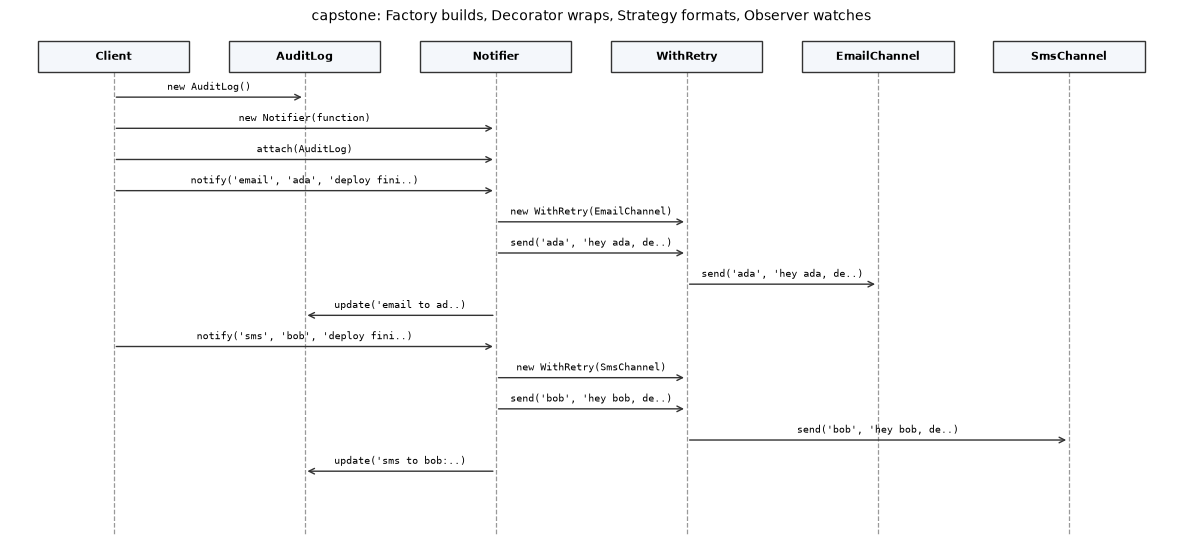

In [3]:
@traced
class EmailChannel:
    def send(self, to, text): return f"email to {to}: {text}"

@traced
class SmsChannel:
    def send(self, to, text): return f"sms to {to}: {text[:20]}"

@traced
class WithRetry:                                   # Decorator around any channel
    def __init__(self, inner, attempts=2):
        self.inner, self.attempts = inner, attempts
    def send(self, to, text):
        for attempt in range(self.attempts):
            try:
                return self.inner.send(to, text)
            except ConnectionError:
                continue
        raise ConnectionError("gave up")

CHANNELS = {"email": EmailChannel, "sms": SmsChannel}   # Factory
def make_channel(name, retry=True):
    channel = CHANNELS[name]()
    return WithRetry(channel) if retry else channel

formal = lambda user, event: f"Dear {user}, {event} has occurred."     # Strategies
casual = lambda user, event: f"hey {user}, {event}!"

@traced
class AuditLog:                                    # Observer
    def __init__(self): self.entries = []
    def update(self, record): self.entries.append(record)

@traced
class Notifier:
    def __init__(self, formatter):
        self.formatter, self.observers = formatter, []
    def attach(self, obs): self.observers.append(obs)
    def notify(self, channel_name, user, event):
        text = self.formatter(user, event)
        result = make_channel(channel_name).send(user, text)
        for obs in self.observers:
            obs.update(result)
        return result

with trace() as t:
    audit = AuditLog()
    notifier = Notifier(casual)
    notifier.attach(audit)
    notifier.notify("email", "ada", "deploy finished")
    notifier.notify("sms", "bob", "deploy finished")
print(*audit.entries, sep="\n")
t.diagram(title="capstone: Factory builds, Decorator wraps, Strategy formats, Observer watches", max_messages=24)

### Lab: Pattern Picker

Describe the pain and get the pattern, its intent, and the notebook that teaches it.

In [4]:
from dplab import pattern_picker

pattern_picker()

Pattern Picker (static preview). Run this cell in JupyterLab for the interactive version.


## Try it yourself

**Exercise 1.** Rewrite the Module 5 `Turnstile` State pattern as a dict of `{(state, event): (next_state, message)}`. Which version would you want when there are 12 states and 8 events?

**Exercise 2.** Replace `WithRetry` in the capstone with a function decorator applied to `send`. What did you lose?

**Exercise 3.** Find a pattern you used unknowingly in code you wrote this month. Name it and say whether naming it changes anything.

**Exercise 4 (challenge).** Add a `Composite` channel to the capstone that sends through several channels at once, and trace it.

<details><summary>Solutions</summary>

```python
# Exercise 1
TABLE = {("Locked", "coin"): ("Unlocked", "unlocked"), ("Locked", "push"): ("Locked", "still locked"),
         ("Unlocked", "push"): ("Locked", "locked again"), ("Unlocked", "coin"): ("Unlocked", "coin returned")}
# The table wins for many simple transitions; classes win when states carry behaviour beyond the transition.

# Exercise 2: a function decorator cannot be applied per instance at runtime, and it fixes the retry count at definition time.

# Exercise 4
class MultiChannel:
    def __init__(self, *channels): self.channels = channels
    def send(self, to, text): return [c.send(to, text) for c in self.channels]
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [5]:
from dplab import quiz

quiz(7)

Checkpoint quiz, Module 7 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. The Pythonic Singleton is
    a) a metaclass
    b) a module: imported once, shared everywhere
    c) a class with __new__ tricks
    d) a global list

Q2. Python's @decorator syntax is the language form of which pattern?
    a) Decorator
    b) Adapter
    c) Proxy
    d) Facade

Q3. When should you apply a design pattern?
    a) at the start of every project
    b) when you actually have the problem it solves
    c) whenever a class has more than three methods
    d) never

Q4. 'Prefer composition over inheritance' is the principle behind
    a) Strategy, Decorator and Bridge
    b) Singleton
    c) Template Method only
    d) Iterator


## Key takeaways

* Functions, generators, decorators, modules and `__getattr__` absorb Strategy, Iterator, Decorator, Singleton and Proxy in everyday Python.
* Use the class form when the collaborator needs state, several methods, identity, or an interface others will extend.
* Patterns are named refactorings: apply one to remove a concrete pain, not to look sophisticated.
* Real systems combine patterns; the trace of the capstone is what "good design" looks like in motion.

**Next track:** where these objects live. [Architecture 1](../architecture/01_Monolith_and_Modular_Monolith.ipynb).

[Previous: GoF 6: Behavioral Patterns, Part 3](06_Behavioral_Part_3.ipynb)  |  [Course Index](../00_Start_Here.ipynb)